In [ ]:
'Pengolahan citra p2'

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


tipe data: <class 'numpy.ndarray'>
shape    : (700, 800, 3)
dtype   : uint8

artinya: 
Tinggi = 700 piksel
lebar = 800 piksel
channel = 3 piksel
total pixel:  560000


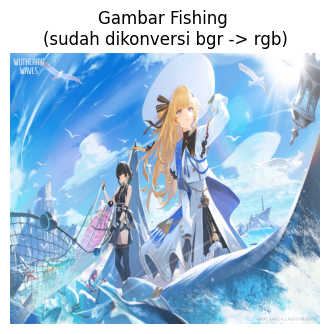

In [58]:
# Baca gambar dari file
#cv2.imread() mengembalikan array numpy !
img_bgr = cv2.imread('wallpaperflare.com_wallpaper13.jpg')

#resize agar tidak terlalu besar
img_bgr = cv2.resize(img_bgr, (800, 700))

#cek tipe data : ternyata sudah array numpy!
print("tipe data:", type(img_bgr))
print("shape    :", img_bgr.shape)
print("dtype   :", img_bgr.dtype)

print()
print("artinya: ")
print(f"Tinggi = {img_bgr.shape[0]} piksel")
print(f"lebar = {img_bgr.shape[1]} piksel")
print(f"channel = {img_bgr.shape[2]} piksel")

#konversi bgr -> rgb untuk ditampilkan di matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("total pixel: ", img_rgb.shape[0] * img_rgb.shape[1])

plt.figure(figsize=(4,6))
plt.imshow(img_rgb)
plt.title('Gambar Fishing \n(sudah dikonversi bgr -> rgb)')
plt.axis('off')
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===
setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

[[173 141 140 153 144 130 134 134]
 [193 159 134 137 141 137 137 138]
 [169 160 141 130 128 135 146 138]
 [135 140 139 137 136 138 171 164]
 [132 135 140 138 148 141 143 193]
 [136 134 136 139 137 137 118 117]
 [139 137 139 138 136 116 120  95]
 [139 141 142 135 126 103 108 101]]

CONTOH baca: f(180, 200) = 162
CONTOH baca: f(181, 201) = 163
CONTOH baca: f(181, 201) = [121 170 239]
total pixel:  560000
total Size Kb:  547
total Size MB:  0.53


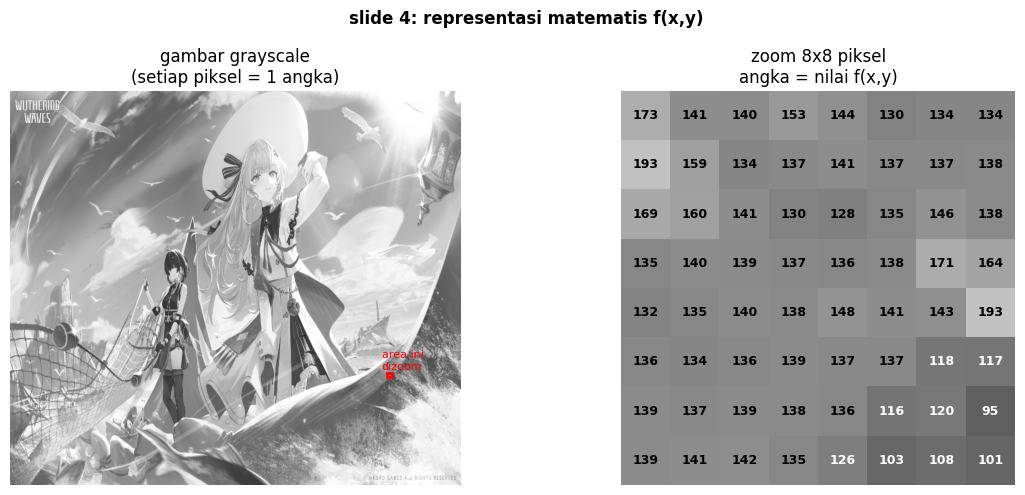

In [56]:
import matplotlib.patches as patches

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#Ambil area kecil
area_kecil = img_gray[500:508, 670:678]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print("setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
print(area_kecil)
print()
print("CONTOH baca:" , f"f(180, 200) = {img_gray[200,180]}")
print("CONTOH baca:" , f"f(181, 201) = {img_gray[201,181]}")
print("CONTOH baca:" , f"f(181, 201) = {img_rgb[201,181]}")

total_pixel_gray = img_gray.shape[0] * img_gray.shape[1]
konversi_kb_gray = (total_pixel_gray*1)/1024
konversi_mb_gray = konversi_kb_gray/1024

print("total pixel: ", total_pixel_gray)
print("total Size Kb: ", round(konversi_kb_gray))
print("total Size MB: ", round(konversi_mb_gray, 2))


fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gambar grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')
rect=patches.Rectangle((670,500),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(660, 495, 'area ini\ndizoom', color='red', fontsize=8)

axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
  for j in range(8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j, i, str(nilai), ha='center', va='center',
                 fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===

Row 0: [157, 175, 204], [115, 147, 182], [111, 146, 184], [128, 157, 196], [120, 147, 188], [100, 136, 179], [105, 139, 185], [104, 140, 186]
Row 1: [178, 195, 219], [136, 162, 202], [106, 139, 183], [110, 141, 183], [115, 146, 185], [109, 142, 182], [108, 141, 189], [107, 144, 190]
Row 2: [149, 172, 202], [136, 165, 200], [113, 146, 187], [101, 135, 180], [101, 133, 177], [110, 139, 181], [119, 150, 195], [107, 143, 191]
Row 3: [108, 139, 181], [111, 145, 189], [108, 145, 190], [109, 142, 186], [107, 142, 185], [107, 144, 192], [147, 175, 209], [140, 169, 204]
Row 4: [102, 137, 184], [106, 140, 186], [111, 145, 190], [110, 143, 186], [121, 153, 196], [113, 146, 190], [120, 148, 181], [178, 196, 217]
Row 5: [106, 141, 186], [104, 140, 185], [106, 141, 187], [110, 143, 191], [106, 142, 192], [111, 140, 187], [88, 124, 166], [92, 122, 157]
Row 6: [112, 144, 187], [109, 142, 188], [108, 144, 191], [107, 143, 191], [106, 141, 186], [86, 121, 165], 

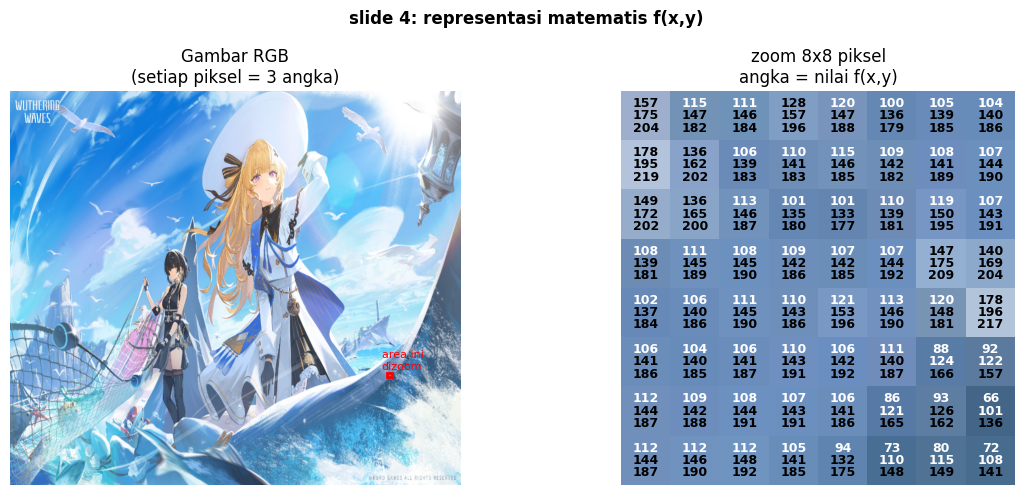

In [57]:
import matplotlib.patches as patches

#Ambil area kecil
area_kecil_rgb = img_rgb[500:508, 670:678]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print()

for row_index, row in enumerate(area_kecil_rgb):
    row_str = []
    for pixel in row:
        row_str.append(f"[{pixel[0]}, {pixel[1]}, {pixel[2]}]")
    print(f"Row {row_index}: {', '.join(row_str)}")

print()
print("CONTOH baca:" , f"f(210, 190) = {img_rgb[210,190]}")
print("CONTOH baca:" , f"f(211, 191) = {img_rgb[211,191]}")

total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
konversi_kb = (total_pixel*3)/1024
konversi_mb = konversi_kb/1024

print("total pixel: ", total_pixel)
print("total Size Kb: ", round(konversi_kb))
print("total Size MB: ", round(konversi_mb, 2))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_rgb, vmin=0, vmax=255)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')
rect=patches.Rectangle((670,500),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(660, 495, 'area ini\ndizoom', color='red', fontsize=8)

def tentukan_warna(skor):
  match skor:
      case r if r < 125:
        return 'white'
      case _:
        return 'black'

axes[1].imshow(area_kecil_rgb)
for i in range(8):
  for j in range(8):
    nilai_rgb = area_kecil_rgb[i,j]
    offsets = [-0.25, 0 ,0.25]
    for mn in range(3):
      nilai_rgb_satuan = nilai_rgb[mn]
      hasil_cek = tentukan_warna(nilai_rgb_satuan)
      axes[1].text(j, i + offsets[mn], str(nilai_rgb_satuan), ha='center', va='center',fontsize=9, color=hasil_cek, fontweight='bold')
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()